<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [3]:
# 1. Normalizar datos

# Separar variables numéricas y categóricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas: {num_cols}")
print(f"Variables categóricas: {cat_cols}")

# a) Variables numéricas: imputar nulos con la media y normalizar con MinMaxScaler
df_num = df[num_cols].copy()
df_num = df_num.fillna(df_num.mean())

scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=num_cols,
    index=df.index
)
print(f"\nVariables numéricas normalizadas: {df_num_scaled.shape}")
print(df_num_scaled.head())

# b) Variables categóricas: one-hot encoding con get_dummies
df_cat = pd.get_dummies(df[cat_cols], drop_first=False)
print(f"\nVariables categóricas codificadas (one-hot): {df_cat.shape}")
print(df_cat.head())

print("""
Explicación de la codificación con get_dummies:
- get_dummies transforma cada categoría única en una columna binaria (0/1).
- Por ejemplo, si 'traccion_tipo' tiene valores ['dos', 'cuatro', 'todas'],
  se generan 3 columnas: traccion_tipo_dos, traccion_tipo_cuatro, traccion_tipo_todas.
- Para una observación con 'cuatro', solo esa columna tendrá un 1, las otras 0.
- Esto permite que algoritmos numéricos (como KMeans) trabajen con datos categóricos.
""")

# c) Concatenar ambos datasets
df_procesado = pd.concat([df_num_scaled, df_cat], axis=1)
print(f"\ndf_procesado final: {df_procesado.shape}")
df_procesado.head()

Variables numéricas: ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
Variables categóricas: ['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

Variables numéricas normalizadas: (36791, 5)
       year  desplazamiento  cilindros       co2  consumo_litros_milla
0  0.000000        0.243590   0.142857  0.398014              0.331027
1  0.000000        0.461538   0.285714  0.527672              0.475113
2  0.029412        0.243590   0.142857  0.424351              0.360294
3  0.029412        0.461538   0.285714  0.527672              0.475113
4  0.088235        0.410256   0.285714  0.424351              0.360294

Variables categóricas codificadas (one-hot): (36791, 31)
   clase_tipo_Camionetas  clase_tipo_Coche Familiar  \
0                  False                      False   
1                  False                      False   
2                  False                      False   
3             

,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [4]:
# 2. Ajuste de KMeans con 8 clusters

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans.fit(df_procesado)

# Asignar cluster a cada individuo
df['cluster'] = kmeans.labels_

# Centroides
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df_procesado.columns
)
print("=" * 60)
print("CENTROIDES DE CADA CLUSTER (primeras 6 variables)")
print("=" * 60)
print(centroides.iloc[:, :6].round(3))

print("\n" + "=" * 60)
print("CANTIDAD DE OBSERVACIONES POR CLUSTER")
print("=" * 60)
print(df['cluster'].value_counts().sort_index())

# Resumen por cluster: promedio de variables numéricas
print("\n" + "=" * 60)
print("PROMEDIO DE VARIABLES NUMÉRICAS POR CLUSTER")
print("=" * 60)
resumen_num = df.groupby('cluster')[num_cols].mean().round(3)
print(resumen_num)

# Moda de variables categóricas por cluster
print("\n" + "=" * 60)
print("MODA DE VARIABLES CATEGÓRICAS POR CLUSTER")
print("=" * 60)
resumen_cat = df.groupby('cluster')[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'N/A')
print(resumen_cat)

CENTROIDES DE CADA CLUSTER (primeras 6 variables)
    year  desplazamiento  cilindros    co2  consumo_litros_milla  \
0  0.427           0.224      0.174  0.305                 0.226   
1  0.569           0.170      0.146  0.241                 0.156   
2  0.408           0.331      0.257  0.354                 0.282   
3  0.477           0.451      0.327  0.410                 0.343   
4  0.384           0.586      0.431  0.510                 0.455   
5  0.589           0.362      0.300  0.354                 0.282   
6  0.452           0.563      0.406  0.502                 0.443   
7  0.580           0.270      0.210  0.305                 0.226   

   clase_tipo_Camionetas  
0                  0.126  
1                  0.008  
2                  0.181  
3                  0.304  
4                  0.259  
5                  0.002  
6                  0.435  
7                  0.026  

CANTIDAD DE OBSERVACIONES POR CLUSTER
cluster
0    2689
1    7384
2    6057
3    4674
4    41

### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

Calculando inercia para distintos K...
  K=  5: inercia = 102310.09


  K= 10: inercia = 84705.94


  K= 20: inercia = 67073.43


  K= 30: inercia = 55953.93


  K= 50: inercia = 44887.89


  K= 75: inercia = 36797.32


  K=100: inercia = 30896.22


  K=200: inercia = 17625.99


  K=300: inercia = 11234.82


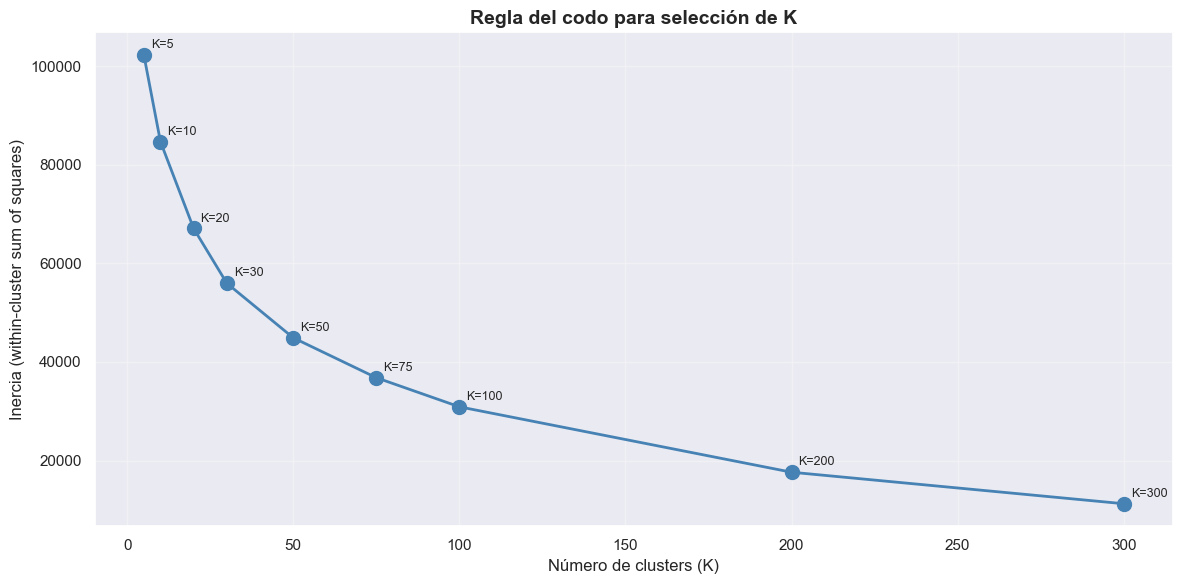


Conclusiones:
- La inercia decae rápido entre K=5 y K=30, lo que indica que aumentar
  el número de clusters en este rango mejora significativamente la cohesión interna.
- A partir de K=50-75 la curva se aplana, indicando rendimientos decrecientes.
- El 'codo' aparente sugiere que K entre 20 y 30 es un buen balance.
- Más allá de 100 clusters no aporta mejoras sustanciales en la inercia.


In [5]:
# 3. Regla del codo

clusters_test = [5, 10, 20, 30, 50, 75, 100, 200, 300]
inercias = []

print("Calculando inercia para distintos K...")
for k in clusters_test:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_procesado)
    inercias.append(km.inertia_)
    print(f"  K={k:3d}: inercia = {km.inertia_:.2f}")

# Gráfico de la regla del codo
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(clusters_test, inercias, marker='o', linewidth=2, markersize=10, color='steelblue')
ax.set_xlabel('Número de clusters (K)', fontsize=12)
ax.set_ylabel('Inercia (within-cluster sum of squares)', fontsize=12)
ax.set_title('Regla del codo para selección de K', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Etiquetar puntos
for k, inercia in zip(clusters_test, inercias):
    ax.annotate(f'K={k}', xy=(k, inercia), xytext=(5, 5),
                textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

print("\nConclusiones:")
print("- La inercia decae rápido entre K=5 y K=30, lo que indica que aumentar")
print("  el número de clusters en este rango mejora significativamente la cohesión interna.")
print("- A partir de K=50-75 la curva se aplana, indicando rendimientos decrecientes.")
print("- El 'codo' aparente sugiere que K entre 20 y 30 es un buen balance.")
print("- Más allá de 100 clusters no aporta mejoras sustanciales en la inercia.")

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [6]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [7]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



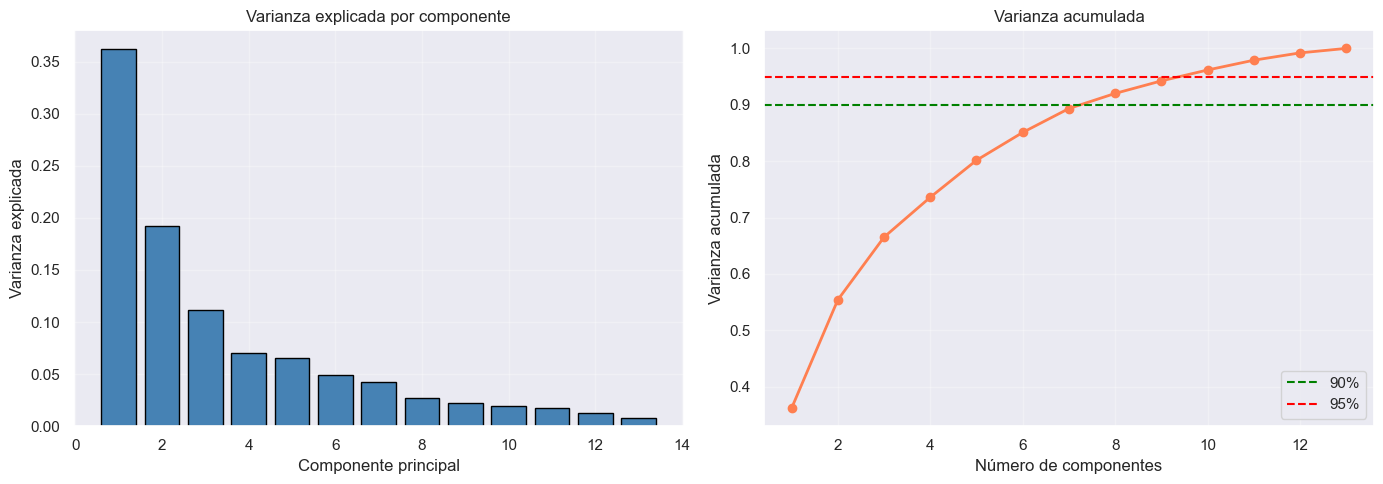


Componentes necesarios para 90% de varianza: 8
Componentes necesarios para 95% de varianza: 10

LOADINGS (contribución de cada variable a las componentes)
                                PC1    PC2
alcohol                       0.144  0.484
malic_acid                   -0.245  0.225
ash                          -0.002  0.316
alcalinity_of_ash            -0.239 -0.011
magnesium                     0.142  0.300
total_phenols                 0.395  0.065
flavanoids                    0.423 -0.003
nonflavanoid_phenols         -0.299  0.029
proanthocyanins               0.313  0.039
color_intensity              -0.089  0.530
hue                           0.297 -0.279
od280/od315_of_diluted_wines  0.376 -0.164
proline                       0.287  0.365


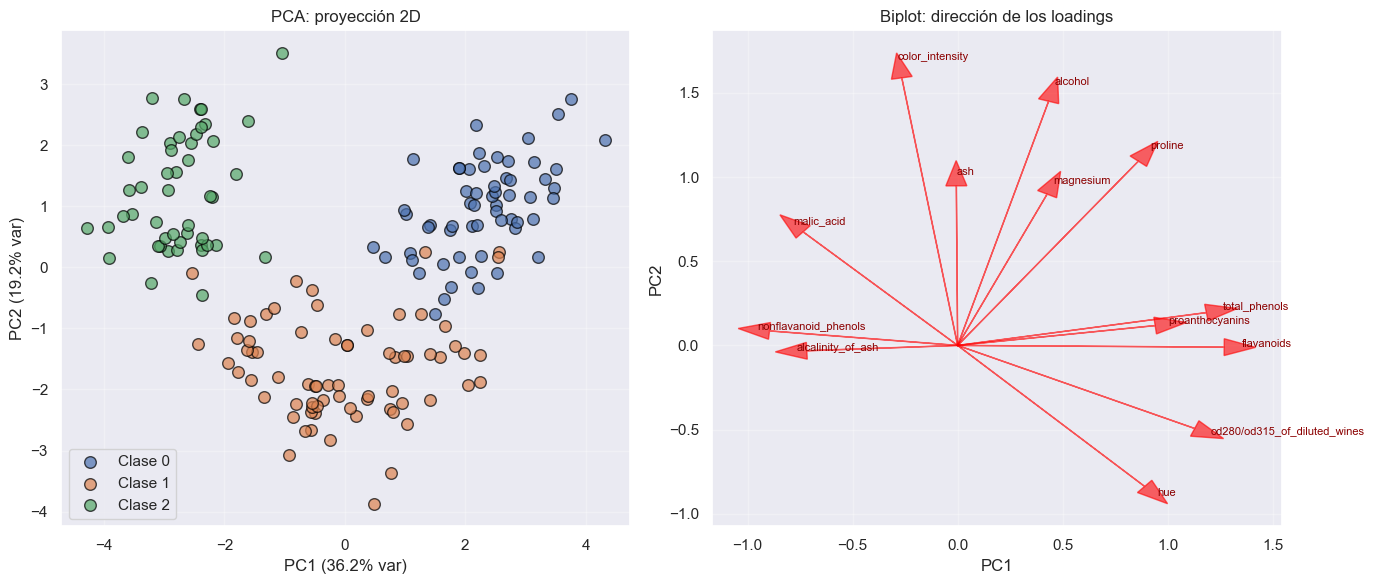


Interpretación:
- Las primeras 2 componentes explican 55.4% de la varianza.
- Las 3 clases de vino se separan claramente en el espacio 2D de PCA.
- Variables con mayor influencia en PC1: alcohol, total_phenols, flavanoids.
- Variables con mayor influencia en PC2: color_intensity, alcalinity_of_ash.


In [8]:
# 1. Análisis detallado con PCA
from sklearn.preprocessing import StandardScaler

X_wine = wine[features].values
y_wine = wine[target].values

# Estandarizar (PCA es sensible a la escala)
scaler_w = StandardScaler()
X_scaled = scaler_w.fit_transform(X_wine)

# PCA completo para analizar varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

# Gráfico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(var_exp) + 1), var_exp, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(var_exp) + 1), var_exp_acum, marker='o', color='coral', linewidth=2)
axes[1].axhline(0.90, color='green', linestyle='--', label='90%')
axes[1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ¿Cuántos componentes para 90% y 95%?
n_90 = np.argmax(var_exp_acum >= 0.90) + 1
n_95 = np.argmax(var_exp_acum >= 0.95) + 1
print(f"\nComponentes necesarios para 90% de varianza: {n_90}")
print(f"Componentes necesarios para 95% de varianza: {n_95}")

# PCA con 2 componentes para visualización
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# Análisis de loadings
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
print("\n" + "=" * 60)
print("LOADINGS (contribución de cada variable a las componentes)")
print("=" * 60)
print(loadings.round(3))

# Visualización 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter de proyección
for clase in np.unique(y_wine):
    mask = y_wine == clase
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Clase {clase}',
                     alpha=0.7, s=70, edgecolor='black')
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[0].set_title('PCA: proyección 2D')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biplot: loadings sobre el scatter
for i, var in enumerate(features):
    axes[1].arrow(0, 0, loadings.iloc[i, 0]*3, loadings.iloc[i, 1]*3,
                  head_width=0.1, color='red', alpha=0.6)
    axes[1].text(loadings.iloc[i, 0]*3.2, loadings.iloc[i, 1]*3.2,
                 var, fontsize=8, color='darkred')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Biplot: dirección de los loadings')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretación:")
print(f"- Las primeras 2 componentes explican {(var_exp[0] + var_exp[1])*100:.1f}% de la varianza.")
print("- Las 3 clases de vino se separan claramente en el espacio 2D de PCA.")
print("- Variables con mayor influencia en PC1: alcohol, total_phenols, flavanoids.")
print("- Variables con mayor influencia en PC2: color_intensity, alcalinity_of_ash.")



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



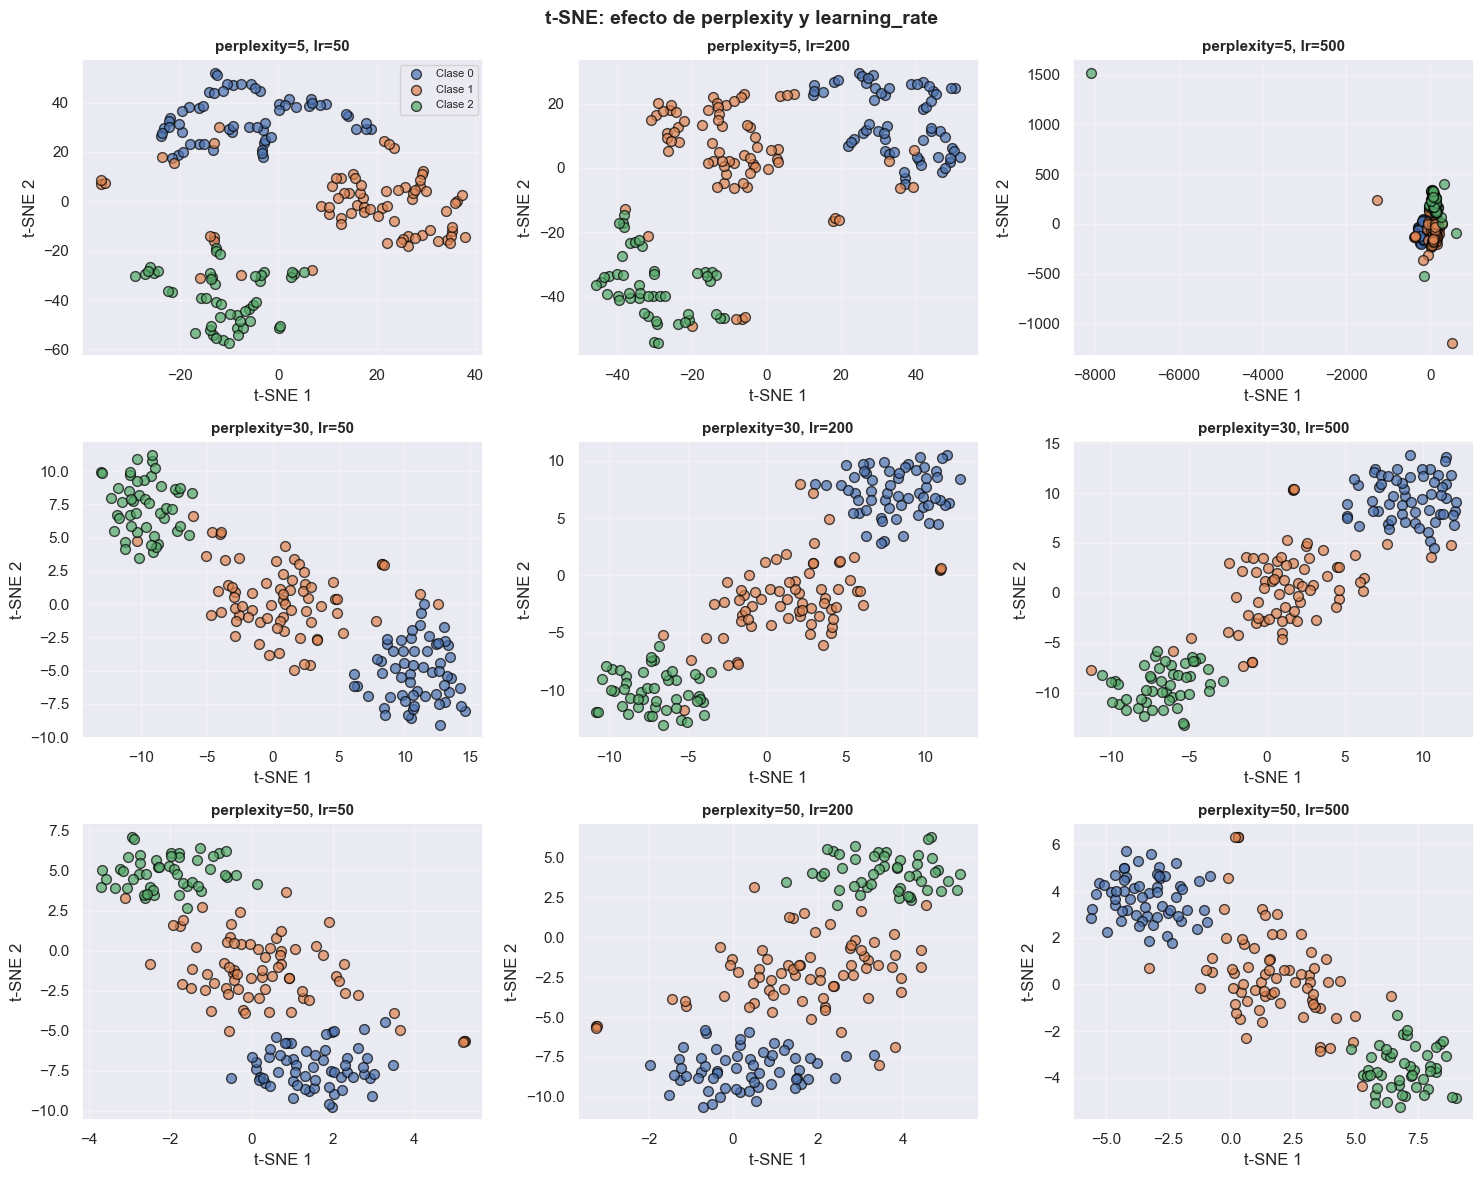


Interpretación:
- Valores bajos de perplexity (5) tienden a separar grupos pequeños y locales.
- Valores altos de perplexity (50) buscan estructuras más globales.
- El learning_rate afecta la dispersión final pero no la estructura general.
- En todos los casos, las 3 clases de vino quedan visualmente separadas,
  confirmando que la estructura es robusta a la elección de hiperparámetros.


In [9]:
# 2. Análisis detallado con t-SNE

perplexities = [5, 30, 50]
learning_rates = [50, 200, 500]

fig, axes = plt.subplots(len(perplexities), len(learning_rates), figsize=(15, 12))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        tsne = TSNE(n_components=2, perplexity=perp, learning_rate=lr,
                    random_state=42, init='pca')
        X_tsne = tsne.fit_transform(X_scaled)

        ax = axes[i, j]
        for clase in np.unique(y_wine):
            mask = y_wine == clase
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f'Clase {clase}',
                       alpha=0.7, s=50, edgecolor='black')
        ax.set_title(f'perplexity={perp}, lr={lr}', fontsize=11, fontweight='bold')
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE: efecto de perplexity y learning_rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("- Valores bajos de perplexity (5) tienden a separar grupos pequeños y locales.")
print("- Valores altos de perplexity (50) buscan estructuras más globales.")
print("- El learning_rate afecta la dispersión final pero no la estructura general.")
print("- En todos los casos, las 3 clases de vino quedan visualmente separadas,")
print("  confirmando que la estructura es robusta a la elección de hiperparámetros.")



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



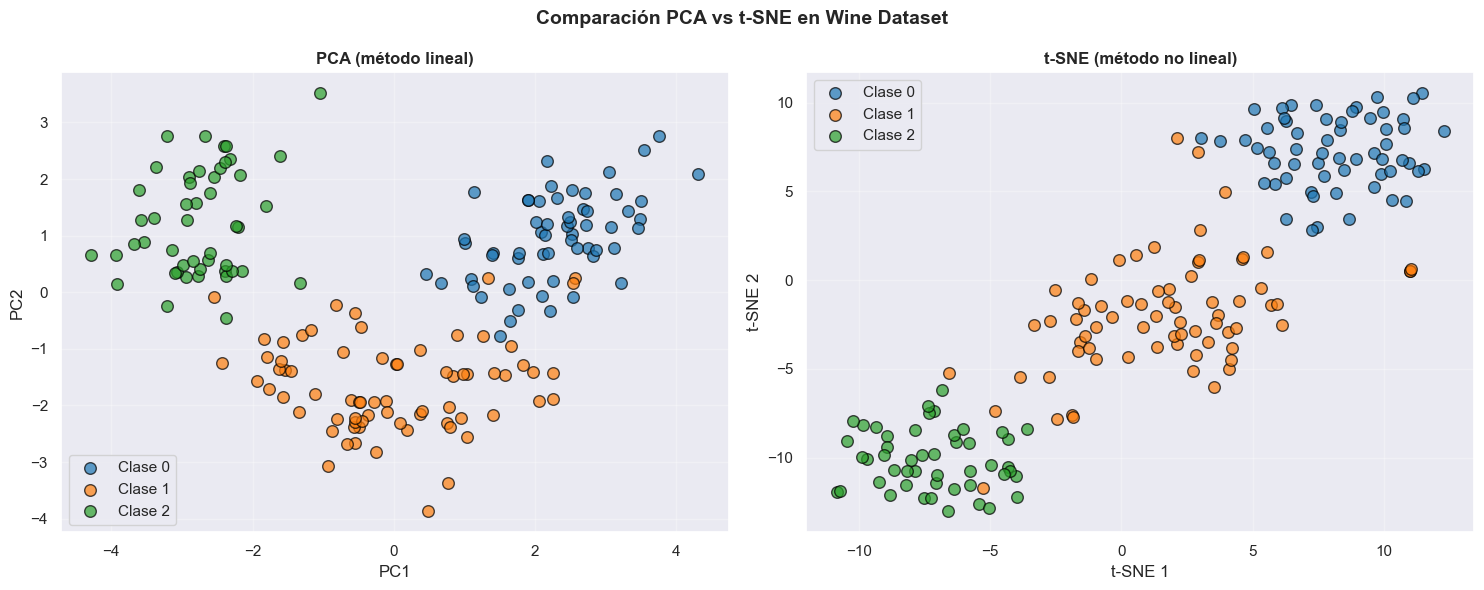

COMPARACIÓN PCA vs t-SNE
              Aspecto                        PCA                      t-SNE
       Tipo de método                     Lineal                  No lineal
    Interpretabilidad            Alta (loadings)                       Baja
Estructura preservada                     Global         Local (vecindades)
  Costo computacional             Bajo (O(n·p²))               Alto (O(n²))
     Reproducibilidad             Determinístico                Estocástico
      Uso recomendado Reducción previa, análisis Visualización exploratoria

CONCLUSIONES:

1. **PCA** es ideal cuando:
   - Se necesita interpretar qué variables explican la varianza.
   - Se desea reducir dimensionalidad antes de aplicar otros modelos.
   - Hay relaciones lineales en los datos.

2. **t-SNE** es preferible cuando:
   - El objetivo es exploración visual de clústeres.
   - Existen patrones no lineales en los datos.
   - No importa la interpretabilidad de las nuevas dimensiones.

3. **Importancia de

In [10]:
# 3. Comparación entre PCA y t-SNE

# PCA con 2 componentes
pca_compare = PCA(n_components=2)
X_pca_compare = pca_compare.fit_transform(X_scaled)

# t-SNE con configuración recomendada
tsne_compare = TSNE(n_components=2, perplexity=30, learning_rate=200,
                    random_state=42, init='pca')
X_tsne_compare = tsne_compare.fit_transform(X_scaled)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors_w = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels_w = ['Clase 0', 'Clase 1', 'Clase 2']

for clase, color, label in zip(np.unique(y_wine), colors_w, labels_w):
    mask = y_wine == clase
    axes[0].scatter(X_pca_compare[mask, 0], X_pca_compare[mask, 1],
                     c=color, label=label, alpha=0.7, s=70, edgecolor='black')
    axes[1].scatter(X_tsne_compare[mask, 0], X_tsne_compare[mask, 1],
                     c=color, label=label, alpha=0.7, s=70, edgecolor='black')

axes[0].set_title('PCA (método lineal)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('t-SNE (método no lineal)', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparación PCA vs t-SNE en Wine Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("COMPARACIÓN PCA vs t-SNE")
print("=" * 60)

comparacion = pd.DataFrame({
    'Aspecto': ['Tipo de método', 'Interpretabilidad', 'Estructura preservada',
                'Costo computacional', 'Reproducibilidad', 'Uso recomendado'],
    'PCA': ['Lineal', 'Alta (loadings)', 'Global',
            'Bajo (O(n·p²))', 'Determinístico', 'Reducción previa, análisis'],
    't-SNE': ['No lineal', 'Baja', 'Local (vecindades)',
              'Alto (O(n²))', 'Estocástico', 'Visualización exploratoria']
})
print(comparacion.to_string(index=False))

print("""
CONCLUSIONES:

1. **PCA** es ideal cuando:
   - Se necesita interpretar qué variables explican la varianza.
   - Se desea reducir dimensionalidad antes de aplicar otros modelos.
   - Hay relaciones lineales en los datos.

2. **t-SNE** es preferible cuando:
   - El objetivo es exploración visual de clústeres.
   - Existen patrones no lineales en los datos.
   - No importa la interpretabilidad de las nuevas dimensiones.

3. **Importancia de la reducción de dimensionalidad**:
   - Permite visualizar datasets de alta dimensionalidad en 2D/3D.
   - Reduce ruido y redundancia entre variables correlacionadas.
   - Acelera el entrenamiento de modelos posteriores.
   - Facilita la comunicación de resultados a audiencias no técnicas.

4. **En el caso Wine**:
   - Las 3 clases son claramente separables tanto con PCA como con t-SNE.
   - PCA es suficiente porque las relaciones son aproximadamente lineales.
   - t-SNE muestra clústeres más compactos pero no aporta información adicional.
""")